In [29]:
import pandas as pd
dataset = pd.read_csv("../processed_data/ml_dataset.csv")

In [30]:
dataset.head()

,TEMPERATURE,PERCIPITATION,WIND_SPEED,CRIME_HAPPENED,YEAR,X,Y,Z,DISTRICT_2,DISTRICT_3,...,DISTRICT_14,DISTRICT_15,HOUR_sin,HOUR_cos,MONTH_sin,MONTH_cos,DAY_sin,DAY_cos,DOW_sin,DOW_cos
0,-0.852737,0.0,-0.150363,1,2010,-0.198612,1.059226,1.153649,0.0,0.0,...,0.0,0.0,-0.965926,-0.258819,-2.449294e-16,1.000000e+00,-0.897805,-0.440394,0.781831,0.623490
1,1.270238,0.0,0.775883,1,2010,0.740723,-1.426578,-1.326069,0.0,0.0,...,0.0,1.0,-0.965926,-0.258819,-5.000000e-01,-8.660254e-01,0.201299,0.979530,0.433884,-0.900969
2,-0.090260,0.0,-0.901374,0,2010,-0.370385,0.703510,0.652626,0.0,0.0,...,0.0,0.0,0.965926,0.258819,-8.660254e-01,-5.000000e-01,0.485302,-0.874347,-0.433884,-0.900969
3,-1.301253,0.0,-0.600969,0,2010,0.597331,0.034533,0.334196,0.0,0.0,...,0.0,0.0,0.866025,-0.500000,8.660254e-01,5.000000e-01,0.968077,-0.250653,0.781831,0.623490
4,1.195485,0.0,-0.475801,1,2010,-0.037500,-0.173231,-0.219045,0.0,0.0,...,0.0,0.0,-0.866025,0.500000,-1.000000e+00,-1.836970e-16,-0.571268,0.820763,0.781831,0.623490


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Features and target
X = dataset.drop(columns=['CRIME_HAPPENED'])
y = dataset['CRIME_HAPPENED']

# Ensure numeric and fill NAs
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# 80/10/10 split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1111, random_state=42, stratify=y_train_val
)

print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

Shapes:
X_train: (332312, 29) y_train: (332312,)
X_val: (41535, 29) y_val: (41535,)
X_test: (41539, 29) y_test: (41539,)


In [32]:
from sklearn.linear_model import LogisticRegression 
# --- Logistic Regression ---
model = LogisticRegression(
    max_iter=1000,  # ensure convergence
    random_state=42
)

# --- Train on training set ---
model.fit(X_train, y_train)

# --- Validate on validation set ---
y_val_pred = model.predict(X_val)

print("\nLogistic Regression Validation Results:")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1-score:", f1_score(y_val, y_val_pred))


Logistic Regression Validation Results:
Accuracy: 0.6504393884675574
Precision: 0.6502235684407904
Recall: 0.6511941448382126
F1-score: 0.6507084947193688


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, scoring='f1', cv=3)
grid.fit(X_train, y_train)
print(grid.best_params_)

{'C': 1}


In [11]:
# --- Test on test set ---
y_test_pred = model.predict(X_test)

print("\nLogistic Regression Test Results:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1-score:", f1_score(y_test, y_test_pred))


Logistic Regression Test Results:
Accuracy: 0.65244709790799
Precision: 0.6527402547279043
Recall: 0.6514516827964755
F1-score: 0.6520953321926886


In [33]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

# --- Initialize the model ---
model = LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    learning_rate=0.01,
    num_leaves=50,
    max_depth=-1,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    n_estimators=500,
    random_state=42
)

# --- Train on training data ---
model.fit(X_train, y_train)

# --- TRAINING DATASET RESULTS ---
y_train_pred = model.predict(X_train)
print("\nLightGBM Training Results:")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall:", recall_score(y_train, y_train_pred))
print("F1-score:", f1_score(y_train, y_train_pred))

print("\n----------------------\n")

# --- VALIDATION DATASET RESULTS ---
y_val_pred = model.predict(X_val)
print("LightGBM Validation Results:")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1-score:", f1_score(y_val, y_val_pred))

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Info] Number of positive: 166156, number of negative: 166156
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019625 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1499
[LightGBM] [Info] Number of data 

In [26]:
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb

model = lgb.LGBMClassifier()

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 100],
    'max_depth': [-1, 10, 20]
}

grid = GridSearchCV(model, param_grid, scoring='f1', cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

[LightGBM] [Info] Number of positive: 110770, number of negative: 110771
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1499
[LightGBM] [Info] Number of data points in the train set: 221541, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499998 -> initscore=-0.000009
[LightGBM] [Info] Start training from score -0.000009
[LightGBM] [Info] Number of positive: 110771, number of negative: 110770
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003965 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1502
[LightGBM] [Info] Number of data points in the train set: 221541, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500002 -> initscore=0.0000

In [55]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

# --- Initialize the model ---
model = LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    learning_rate=0.1,
    num_leaves=100,
    max_depth=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    n_estimators=500,
    random_state=42
)

# --- Train on training data ---
model.fit(X_train, y_train)

# --- VALIDATION PREDICTIONS ---
y_val_pred = model.predict(X_val)
print("LightGBM Validation Results:")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1-score:", f1_score(y_val, y_val_pred))

print("\n----------------------\n")

# --- TEST PREDICTIONS ---
y_test_pred = model.predict(X_test)
print("LightGBM Test Results:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1-score:", f1_score(y_test, y_test_pred))

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Info] Number of positive: 166156, number of negative: 166156
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023939 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1499
[LightGBM] [Info] Number of data 

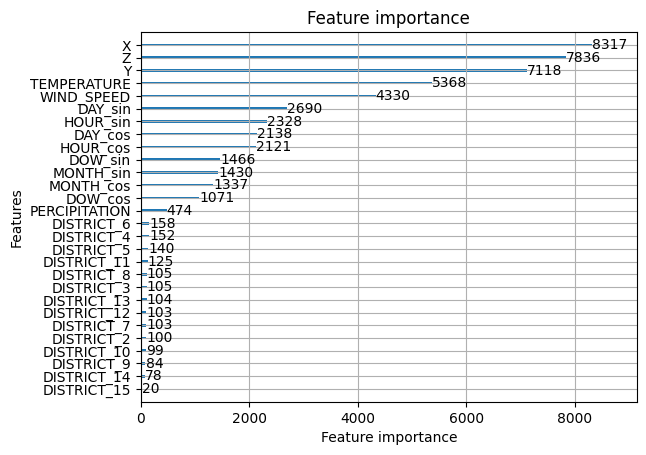

In [35]:
import matplotlib.pyplot as plt
lgb.plot_importance(model)
plt.show()

In [37]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_train, y_train)

# --- TRAINING PREDICTIONS ---
y_train_pred = model.predict(X_train)
print("LightGBM Training Results:")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall:", recall_score(y_train, y_train_pred))
print("F1-score:", f1_score(y_train, y_train_pred))

print("\n----------------------\n")

# --- VALIDATION PREDICTIONS ---
y_val_pred = model.predict(X_val)
print("LightGBM Validation Results:")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1-score:", f1_score(y_val, y_val_pred))

LightGBM Training Results:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0

----------------------

LightGBM Validation Results:
Accuracy: 0.7462140363548814
Precision: 0.7281284853892482
Recall: 0.7858724961479199
F1-score: 0.7558993122293495


In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- Hyperparameter grid ---
param_grid = {
    'n_estimators': [100, 200, 300],      # number of trees
    'max_depth': [None, 10, 20, 30],      # max depth of trees
}

# --- GridSearchCV ---
grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    scoring='f1',    # optimize F1-score
    cv=3,            # 3-fold cross-validation
    verbose=2
)

# --- Fit on training data ---
grid.fit(X_train, y_train)

# --- Best hyperparameters ---
print("Best parameters found:", grid.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END ...................max_depth=None, n_estimators=100; total time=  19.7s
[CV] END ...................max_depth=None, n_estimators=100; total time=  19.7s
[CV] END ...................max_depth=None, n_estimators=100; total time=  20.0s
[CV] END ...................max_depth=None, n_estimators=200; total time=  46.0s
[CV] END ...................max_depth=None, n_estimators=200; total time=  44.2s
[CV] END ...................max_depth=None, n_estimators=200; total time=  38.3s
[CV] END ...................max_depth=None, n_estimators=300; total time=  58.3s
[CV] END ...................max_depth=None, n_estimators=300; total time=  57.7s
[CV] END ...................max_depth=None, n_estimators=300; total time=  58.0s
[CV] END .....................max_depth=10, n_estimators=100; total time=   9.6s
[CV] END .....................max_depth=10, n_estimators=100; total time=   9.4s
[CV] END .....................max_depth=10, n_es

In [41]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_train, y_train)

# --- VALIDATION PREDICTIONS ---
y_val_pred = model.predict(X_val)
print("RandomForestClassifier Validation Results:")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1-score:", f1_score(y_val, y_val_pred))

print("\n----------------------\n")

# --- TEST PREDICTIONS ---
y_test_pred = model.predict(X_test)
print("RandomForestClassifier Test Results:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1-score:", f1_score(y_test, y_test_pred))

RandomForestClassifier Validation Results:
Accuracy: 0.7449380040929336
Precision: 0.7162104726283577
Recall: 0.8113925269645609
F1-score: 0.7608361928842334

----------------------

RandomForestClassifier Test Results:
Accuracy: 0.7462144009244325
Precision: 0.7181248133771275
Recall: 0.8105830805527469
F1-score: 0.7615579480683977


In [45]:
import xgboost as xgb

model = xgb.XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.1,
    max_depth=6,
    n_estimators=200,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)


# --- TRAINING PREDICTIONS ---
y_train_pred = model.predict(X_train)
print("XGBClassifier Training Results:")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall:", recall_score(y_train, y_train_pred))
print("F1-score:", f1_score(y_train, y_train_pred))

print("\n----------------------\n")

# --- VALIDATION PREDICTIONS ---
y_val_pred = model.predict(X_val)
print("XGBClassifier Validation Results:")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1-score:", f1_score(y_val, y_val_pred))

XGBClassifier Training Results:
Accuracy: 0.7519981222465635
Precision: 0.7228983007538009
Recall: 0.8172741279279713
F1-score: 0.767194720963605

----------------------

XGBClassifier Validation Results:
Accuracy: 0.7465511014806789
Precision: 0.7165207831197936
Recall: 0.8159187211093991
F1-score: 0.7629961501227007


In [44]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- Hyperparameter grid ---
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 6, 10],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# --- Initialize XGBClassifier ---
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# --- GridSearchCV ---
grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1',      # optimize F1-score
    cv=3,              # 3-fold cross-validation
    verbose=2
)

# --- Fit on training data ---
grid.fit(X_train, y_train)

# --- Best hyperparameters ---
print("Best parameters found:", grid.best_params_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   1.3s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   1.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1; total time=   0.8s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1; total time=   0.8s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1; total time=   0.9s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   1.7s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   1.7s
[CV] END colsam

In [47]:
import xgboost as xgb

model = xgb.XGBClassifier(
    objective='binary:logistic',
    colsample_bytree=0.8,
    learning_rate=0.1,
    max_depth=10,
    n_estimators=300,
    subsample=1,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# --- VALIDATION ---
y_val_pred = model.predict(X_val)

print("XGBoost Validation Results:")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1-score:", f1_score(y_val, y_val_pred))

print("\n----------------------\n")

# --- TEST ---
y_test_pred = model.predict(X_test)

print("XGBoost Test Results:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1-score:", f1_score(y_test, y_test_pred))

XGBoost Validation Results:
Accuracy: 0.7665342482243891
Precision: 0.7413139195256986
Recall: 0.818807781201849
F1-score: 0.7781362253185988

----------------------

XGBoost Test Results:
Accuracy: 0.7692048436409158
Precision: 0.7462561663143058
Recall: 0.8157831383311667
F1-score: 0.7794723161502541


In [49]:
from catboost import CatBoostClassifier

# Model
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    eval_metric='F1',
    random_state=42,
    verbose=0
)

# Train
model.fit(X_train, y_train, eval_set=(X_val, y_val))

# --- TRAINING PREDICTIONS ---
y_train_pred = model.predict(X_train)
print("CatBoostClassifier Training Results:")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall:", recall_score(y_train, y_train_pred))
print("F1-score:", f1_score(y_train, y_train_pred))

print("\n----------------------\n")

# --- VALIDATION PREDICTIONS ---
y_val_pred = model.predict(X_val)
print("CatBoostClassifier Validation Results:")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1-score:", f1_score(y_val, y_val_pred))

CatBoostClassifier Training Results:
Accuracy: 0.7369670670935747
Precision: 0.7088680116068728
Recall: 0.8042321673607935
F1-score: 0.7535448944778875

----------------------

CatBoostClassifier Validation Results:
Accuracy: 0.7382689298182256
Precision: 0.7092123620682366
Recall: 0.8077330508474576
F1-score: 0.7552734067220458


In [50]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- Base model ---
base_model = CatBoostClassifier(
    verbose=0,
    random_state=42
)

# --- Hyperparameter grid ---
param_grid = {
    'iterations': [200, 300],
    'learning_rate': [0.05, 0.1],
    'depth': [4, 6, 8]
}

# --- GridSearch ---
grid = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    verbose=2,
    n_jobs=-1
)

# --- Fit ONLY on training data ---
grid.fit(X_train, y_train)

# --- Best params ---
print("Best parameters:", grid.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'depth': 8, 'iterations': 300, 'learning_rate': 0.1}


In [52]:
from catboost import CatBoostClassifier

# Model
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=8,
    eval_metric='F1',
    random_state=42,
    verbose=0
)

# Train
model.fit(X_train, y_train, eval_set=(X_val, y_val))

# --- VALIDATION ---
y_val_pred = model.predict(X_val)

print("CatBoostClassifier Validation Results:")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1-score:", f1_score(y_val, y_val_pred))

print("\n----------------------\n")

# --- TEST ---
y_test_pred = model.predict(X_test)

print("CatBoostClassifier Test Results:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1-score:", f1_score(y_test, y_test_pred))

CatBoostClassifier Validation Results:
Accuracy: 0.7449861562537619
Precision: 0.7162162162162162
Recall: 0.8115369799691834
F1-score: 0.760902934537246

----------------------

CatBoostClassifier Test Results:
Accuracy: 0.7458532944943306
Precision: 0.7187848144656783
Recall: 0.8076941595647359
F1-score: 0.7606502369238444
